In [20]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

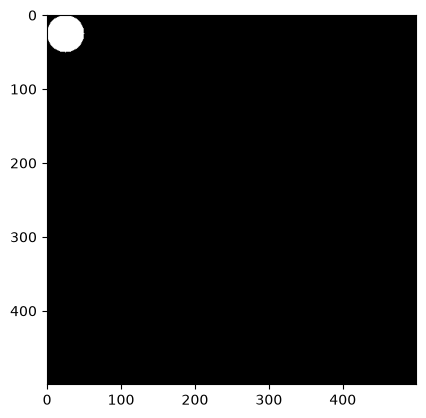

In [23]:
img = np.zeros((500, 500), dtype=np.uint8)
cv2.circle(img, (25, 25), 25, 255, -1)

plt.imshow(img, cmap="gray")
plt.show()

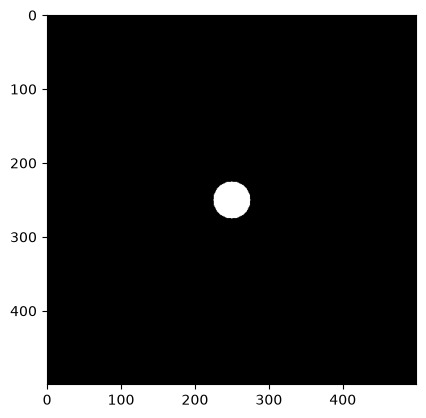

In [ ]:
# displace circle using affine transform

plt.imshow(
    cv2.warpAffine(
        img,
        np.array([[1, 0, 250 - 25], [0, 1, 250 - 25]], dtype=np.float32),
        dsize=img.shape
    ),
    cmap="gray"
)
plt.show()

In [1]:
"""
1) cv2.getRotationMatrix2D(center, angle, scale) then use in cv2.warpAffine(img, rotmat, img.shape[:2])
2) cv2.getPerspectiveTransform(src_points, dst_points) 4 points to create a 3x3 matrix
e.g:
src_pts = np.float32([
    [75, 120],   # Top-Left
    [380, 80],   # Top-Right
    [410, 520],  # Bottom-Right
    [30, 480]    # Bottom-Left
])

width, height = 400, 500
dst_pts = np.float32([
    [0, 0],                  # Top-Left target
    [width - 1, 0],          # Top-Right target
    [width - 1, height - 1], # Bottom-Right target
    [0, height - 1]          # Bottom-Left target
])

M = cv2.getPerspectiveTransform(src_pts, dst_pts)
output_image = cv2.warpPerspective(image, M, (width, height))
"""

None

In [ ]:
"""
Code for homography stitching. assuming you found the matrix from those 4 points
"""

import cv2
import numpy as np

# Load your two images
# Image 1 is the base (anchor), Image 2 will be warped to align with Image 1
img1 = cv2.imread('left_image.jpg')
img2 = cv2.imread('right_image.jpg')

# ASSUMPTION: 'M' is your known 3x3 perspective matrix 
# that transforms coordinates from Image 2 to Image 1.
# M = cv2.getPerspectiveTransform(...) or calculated via features

# --- STEP 1: Calculate the size of the new canvas ---
# Get the corners of Image 2 (the image being warped)
h2, w2 = img2.shape[:2]
corners_img2 = np.float32([[0, 0], [0, h2], [w2, h2], [w2, 0]]).reshape(-1, 1, 2)

# Transform Image 2's corners to see where they land in Image 1's space
transformed_corners = cv2.perspectiveTransform(corners_img2, M)

# Combine these with Image 1's native corners to find the absolute bounding box
h1, w1 = img1.shape[:2]
corners_img1 = np.float32([[0, 0], [0, h1], [w1, h1], [w1, 0]]).reshape(-1, 1, 2)
all_corners = np.concatenate((corners_img1, transformed_corners), axis=0)

# Find minimum and maximum coordinates
[x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
[x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

# --- STEP 2: Handle Negative Shifts (Translation) ---
# If transformed corners land on negative coordinates, we must shift everything
translation_dist = [-x_min, -y_min]

# Create a correction matrix to shift the pixels into positive canvas space
H_translation = np.array([[1, 0, translation_dist[0]], 
                          [0, 1, translation_dist[1]], 
                          [0, 0, 1]])

# Calculate final canvas size
canvas_width = x_max - x_min
canvas_height = y_max - y_min

# --- STEP 3: Warp and Combine ---
# Warp Image 2 using the combined matrix (Translation * M)
output_img = cv2.warpPerspective(img2, H_translation.dot(M), (canvas_width, canvas_height))

# Paste Image 1 directly into its shifted position on the canvas
output_img[translation_dist[1]:h1 + translation_dist[1], 
           translation_dist[0]:w1 + translation_dist[0]] = img1

# Save or display result
cv2.imwrite('panorama_result.jpg', output_img)